<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter6/6_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K 평균
비지도학습 중 대표중인 클러스터 방식 사용

비지도학습은 픽셀 평균등으로 훈련해서 분류할수 없기에 이런 방법을 사용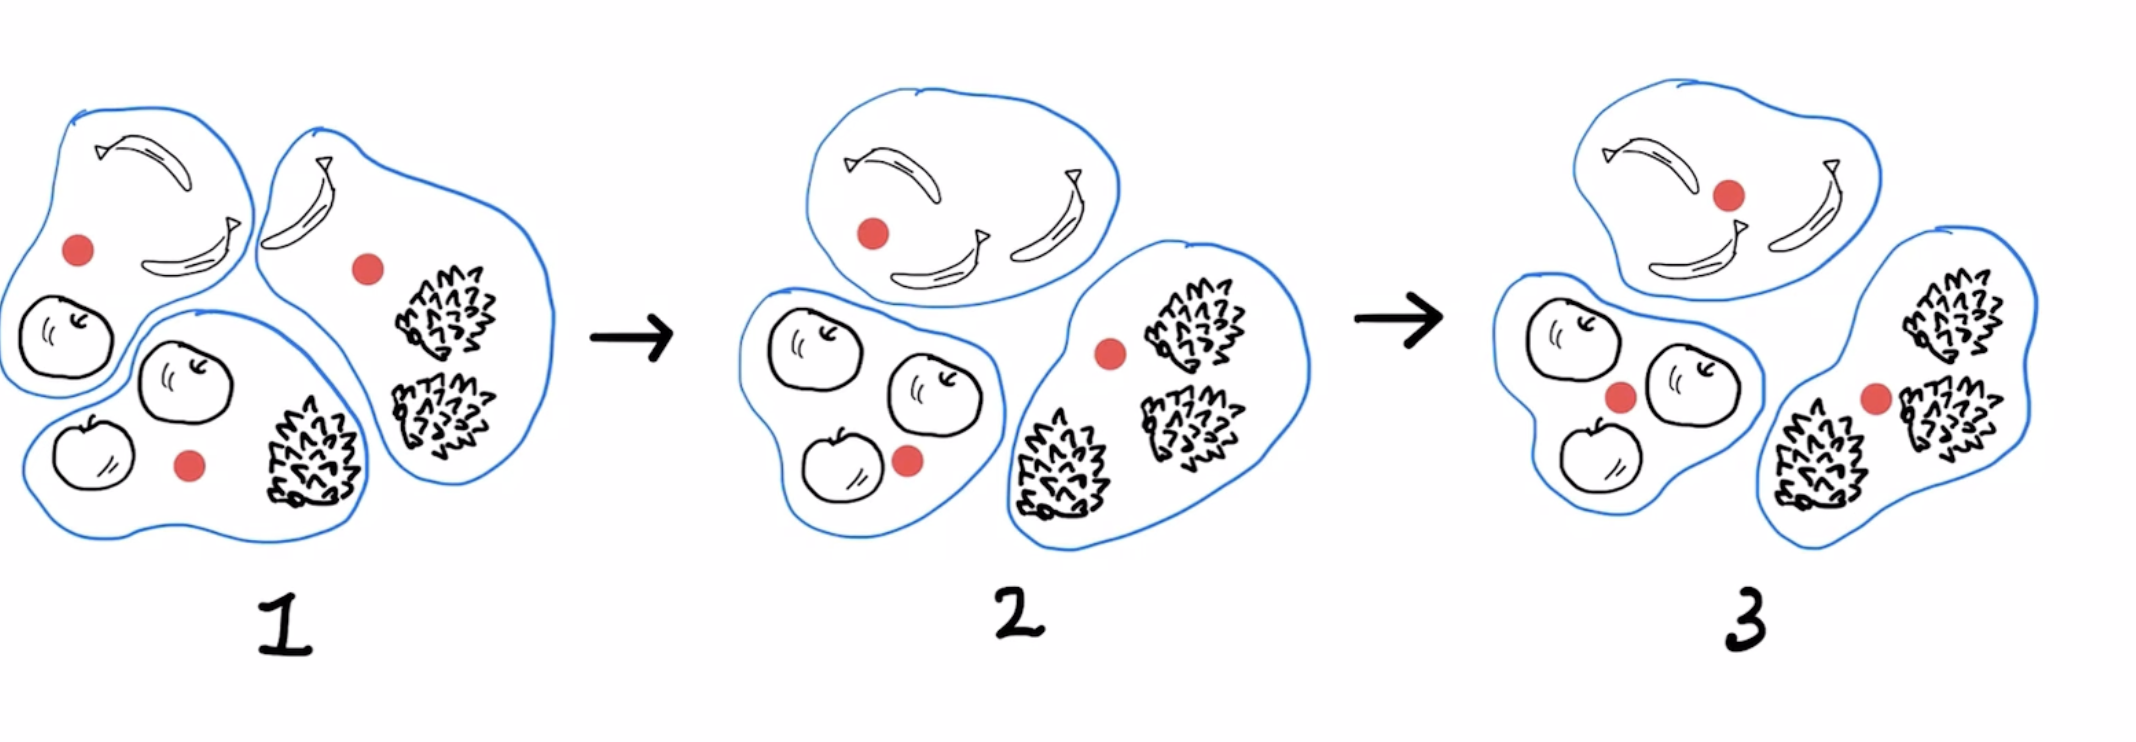

## Kmeans 클래스
k평균은 클러스터 개수인 센트로이드의 개수를 지정해줘야한다는 단점이 있다.

물론 적절한 센트로이드 개수를 구하는 방법도 있다.

In [1]:
#데이터 가져와서 로드하기
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-29 00:55:13--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-29 00:55:13--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-29 00:55:13--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... conne

In [3]:
import numpy as np

fruits = np.load('fruits_300.npy')

#2차원으로 변환
fruits_2d = fruits.reshape(-1, 100*100)

In [4]:
#k평균 알고리즘 모델 훈련
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [5]:
#군집된 결과는 labels_ 속성에 저장.(0, 1, 2 세개의 개체로 저장)
print(km.labels_)

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [6]:
#0, 1, 2 샘플의 개수 확인
print(np.unique(km.labels_, return_counts= True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [7]:
#각 클러스터 확인
import matplotlib.pyplot as plt

#그리기 위한 유틸리티 함수
def draw_fruits(arr, ratio=1):
    n = len(arr)    # n은 샘플 개수입니다
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

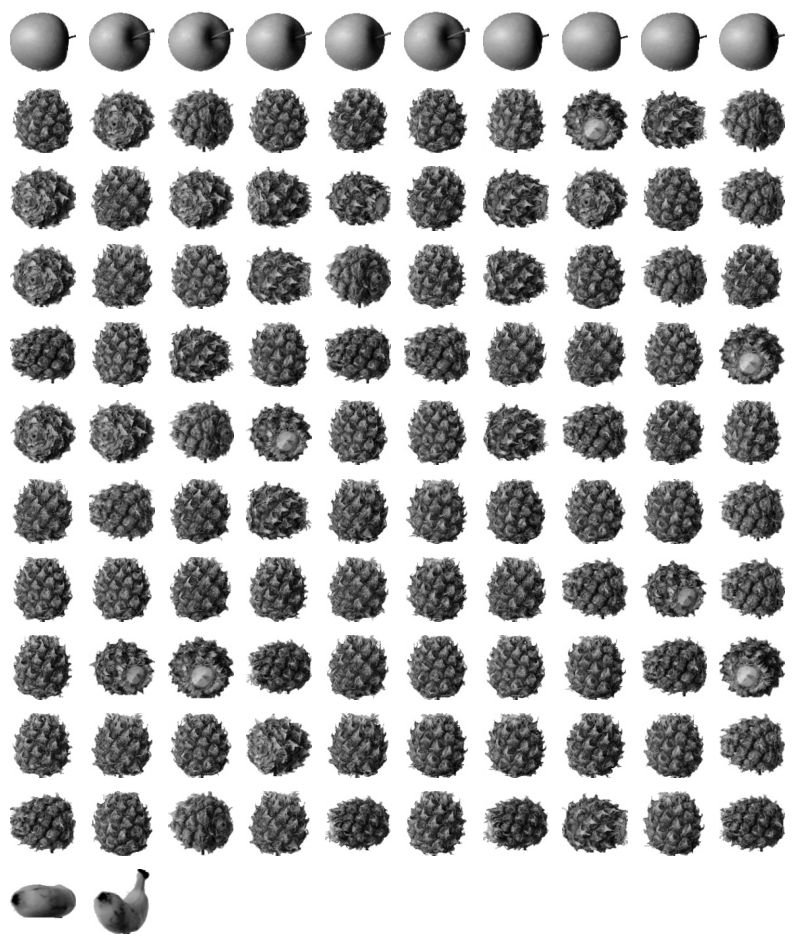

In [8]:
#0 클러스터 그려보기
draw_fruits(fruits[km.labels_==0])

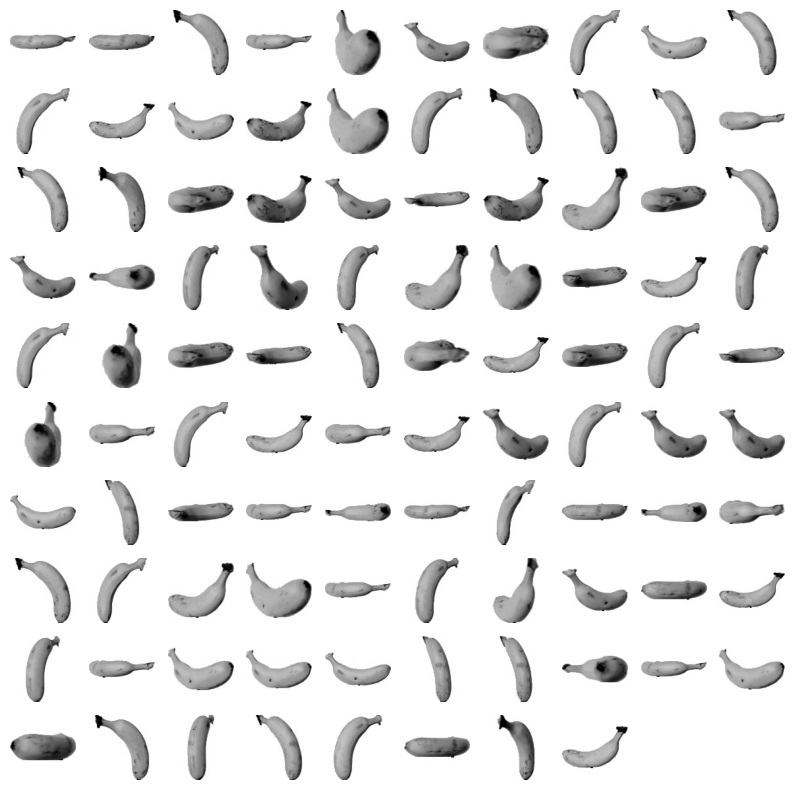

In [9]:
#1 클러스터 그려보기
draw_fruits(fruits[km.labels_==1])

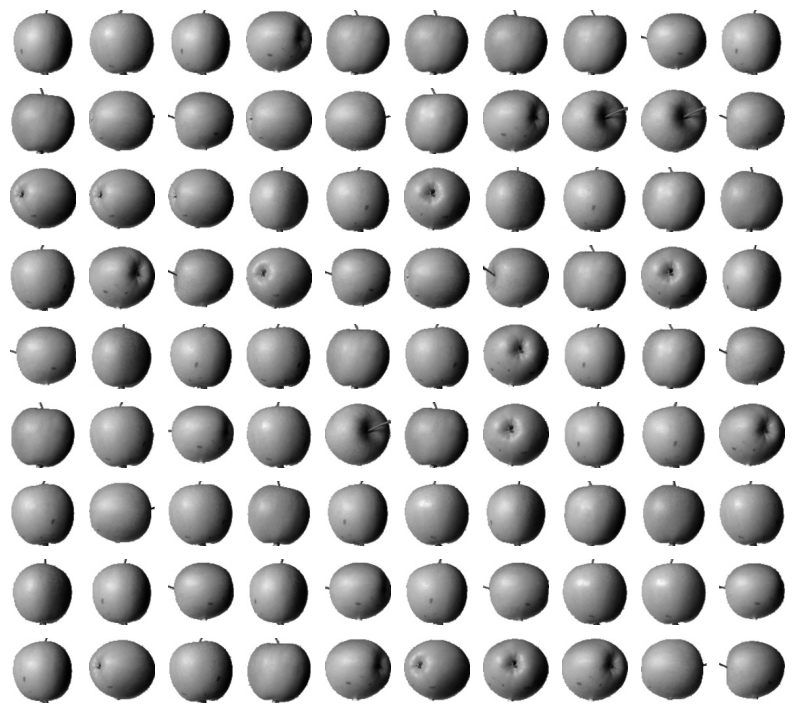

In [10]:
#2 클러스터 그려보기
draw_fruits(fruits[km.labels_==2])

## 클러스터 중심
KMeans 클래스가 최정적으로 찾은 클러스터 중심은 cluster_centers에 저장되어있다.

이 cluster_centers_의 배열은 fruits_2d 샘플의 클러스터 중심이기에 각 중심을 이미지로 출력하려면 100*100 크기의 2차원 배열로 바꿔줘야한다.

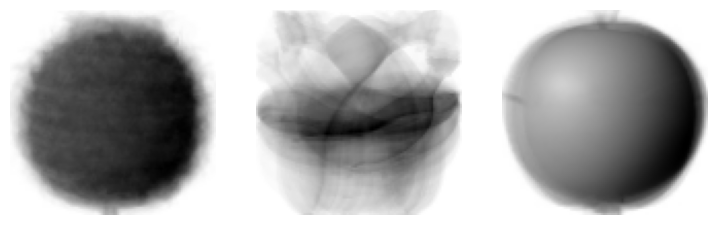

In [11]:
#배열 변환 후 그리기
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)

In [12]:
#훈련 데이터 샘플에서 클러스 중심까지 거리로 변환해주는 transfrom() 메서드
#예시로 인덱스가 100인 샘플의 메서드 적용(각 값이 각 클러스터 중심과의 거리)
print(km.transform(fruits_2d[100:101]))

[[3400.24197319 8837.37750892 5279.33763699]]


In [13]:
#인덱스 100의 예측
print(km.predict(fruits_2d[100:101]))

[0]


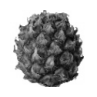

In [14]:
#실제 출력
draw_fruits(fruits[100:101])

In [16]:
#클러스터 중심을 몇번 옮겨는지 횟수(알고리즘 반복 횟수)
print(km.n_iter_)

4


## 최적의 k 값 찾기

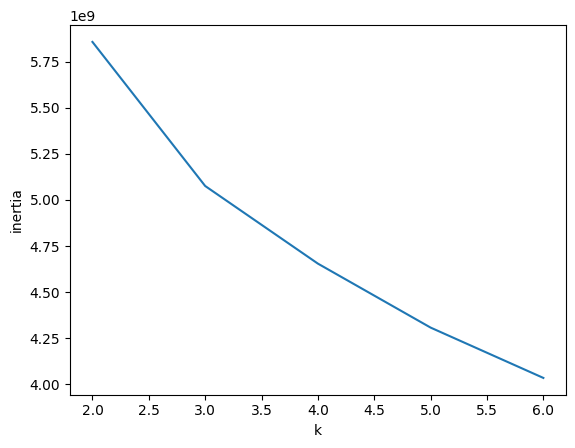

In [17]:
#엘보우 방법(그래프가 꺾이는 부분이 최적이라 생각)
#inertia는 k 평균 알고리즘에서 클러스터 중심과 클러스터에 속한 샘플 사이의 거리의 제곱 합(얼마나 가깝게 모였는지)
#일반적으로 클러스터 개수가 늘어가면 클러스터 개개의 크기는 줄어들기 때문에 이너셔도 줄어듦.
inertia = []

#k = 2부터 7까지 이너셔 구하기
for k in range(2, 7):
  km = KMeans(n_clusters= k, n_init='auto', random_state=42)
  km.fit(fruits_2d)
  inertia.append(km.inertia_)

#그래프 그려보기(3에서 꺾이는 모습이 보인다)
plt.plot(range(2, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()